In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import torch
import math
from sklearn.cluster import DBSCAN
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
kaggle_df = pd.read_csv('/content/drive/MyDrive/thesis/kaggle/final/kaggle_df.csv')

kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     1000 non-null   object 
 1   Display_Name                 1000 non-null   object 
 2   Gender                       1000 non-null   object 
 3   notebook_url                 1000 non-null   object 
 4   code_location                1000 non-null   object 
 5   labels                       1000 non-null   object 
 6   top_labels                   1000 non-null   object 
 7   code_sections                1000 non-null   object 
 8   markdown_sections            1000 non-null   object 
 9   all_sections                 1000 non-null   object 
 10  only_code_in_code_sections   1000 non-null   object 
 11  number_of_lines              1000 non-null   float64
 12  names_set                    1000 non-null   object 
 13  num_of_sections    

In [3]:
kaggle_df.drop_duplicates(subset=['only_code_in_code_sections'], inplace=True)

kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     999 non-null    object 
 1   Display_Name                 999 non-null    object 
 2   Gender                       999 non-null    object 
 3   notebook_url                 999 non-null    object 
 4   code_location                999 non-null    object 
 5   labels                       999 non-null    object 
 6   top_labels                   999 non-null    object 
 7   code_sections                999 non-null    object 
 8   markdown_sections            999 non-null    object 
 9   all_sections                 999 non-null    object 
 10  only_code_in_code_sections   999 non-null    object 
 11  number_of_lines              999 non-null    float64
 12  names_set                    999 non-null    object 
 13  num_of_sections          

In [7]:
model_name = "neulab/codebert-python"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

code_snippets = kaggle_df.only_code_in_code_sections.tolist()

# Step 1: Encode the code snippets using CodeBERT
def get_embeddings(code_snippet):
    inputs = tokenizer(code_snippet, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the last hidden state of the [CLS] token as the embedding
    return outputs.last_hidden_state[:, 0, :].numpy()

# Get embeddings for all code snippets
embeddings = np.vstack([get_embeddings(snippet) for snippet in code_snippets])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/703 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at neulab/codebert-python and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
min_samples = 10 ** (math.floor(math.log10(len(code_snippets))) - 1)

min_samples

10

In [9]:
# Step 2: Apply DBSCAN for clustering and outlier detection
dbscan = DBSCAN(eps=0.1, min_samples=min_samples, metric='cosine', n_jobs=-1)
db_labels = dbscan.fit_predict(embeddings)

# Step 3: Identify and handle outliers
outliers = np.where(db_labels == -1)[0]

# Output some statistics
print(f'Removed {len(outliers)} outliers.')
print(f'Retained {len(db_labels) - len(outliers)} code snippets.')

Removed 107 outliers.
Retained 892 code snippets.


In [10]:
# Remove outliers from the DataFrame
kaggle_df.reset_index(drop=True, inplace=True)
kaggle_df = kaggle_df[~kaggle_df.index.isin(outliers)]

kaggle_df.Gender.value_counts()

,count
Gender,
male,501
female,391


In [11]:
X=kaggle_df.drop('Gender',axis=1)
Y=kaggle_df.Gender

In [12]:
X_nontext=X.select_dtypes(exclude=['object'])
X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
Index: 892 entries, 0 to 998
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   number_of_lines              892 non-null    float64
 1   num_of_sections              892 non-null    int64  
 2   token_count                  892 non-null    int64  
 3   variables_count              892 non-null    int64  
 4   function_count               892 non-null    int64  
 5   loop_count                   892 non-null    int64  
 6   condition_count              892 non-null    int64  
 7   single_line_comment_density  892 non-null    float64
 8   function_density             892 non-null    float64
 9   loop_density                 892 non-null    float64
 10  condition_density            892 non-null    float64
 11  comment_tokens_density       892 non-null    float64
 12  avg_var_name_length          892 non-null    float64
 13  comment_to_code_ratio    

In [13]:
X_train_nontext, X_test_nontext, y_train, y_test = train_test_split(X_nontext, Y, test_size=0.25, random_state=0,stratify=Y)

In [14]:
def print_test_confusion_matrix():
  disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred), display_labels=grid_search.classes_)

  fig, ax = plt.subplots(figsize=(15,10))
  disp.plot(ax=ax)

  plt.show()

# Decision Tree - All

In [15]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',DecisionTreeClassifier(random_state = 42))])

In [16]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6009650993154527


In [17]:
param_grid = {'classifier__max_depth' : [7, 9, 11, None],
              'classifier__min_samples_split' : [4, 8, 12],
              'classifier__criterion' :['gini', 'entropy']
             }

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found:  {'classifier__criterion': 'gini', 'classifier__max_depth': 7, 'classifier__min_samples_split': 12}
Best F1 score found:  0.6202645403614039
Test set F1 score:  0.6220338983050847


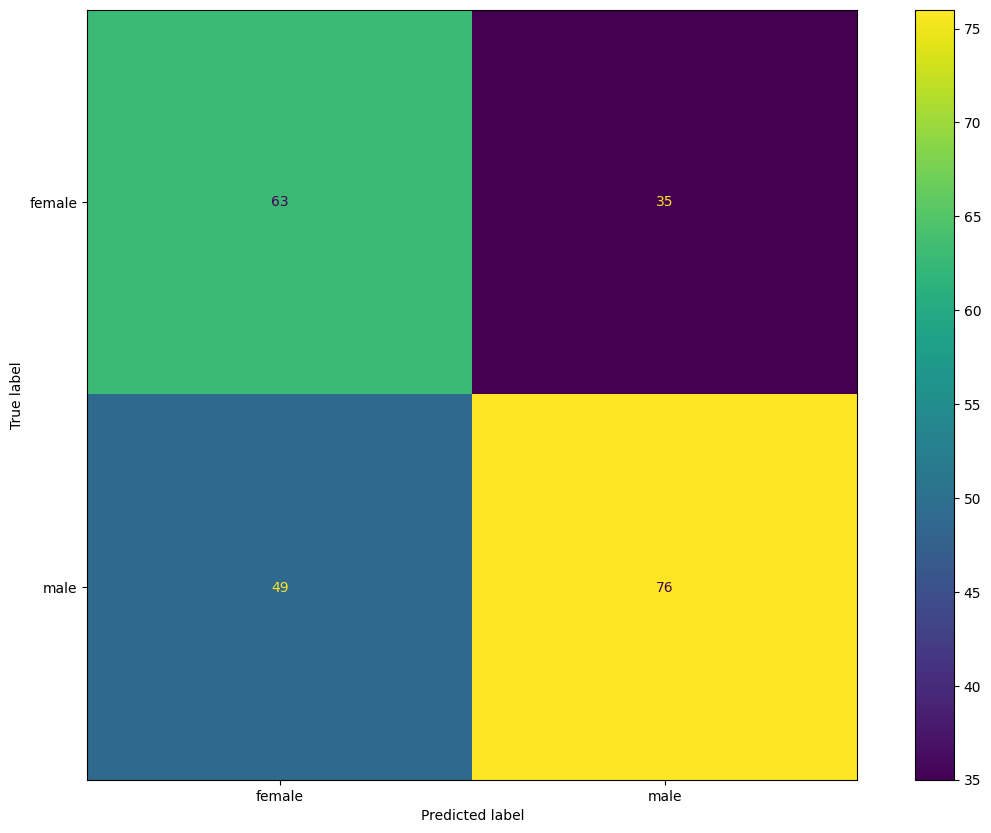

In [18]:
print_test_confusion_matrix()

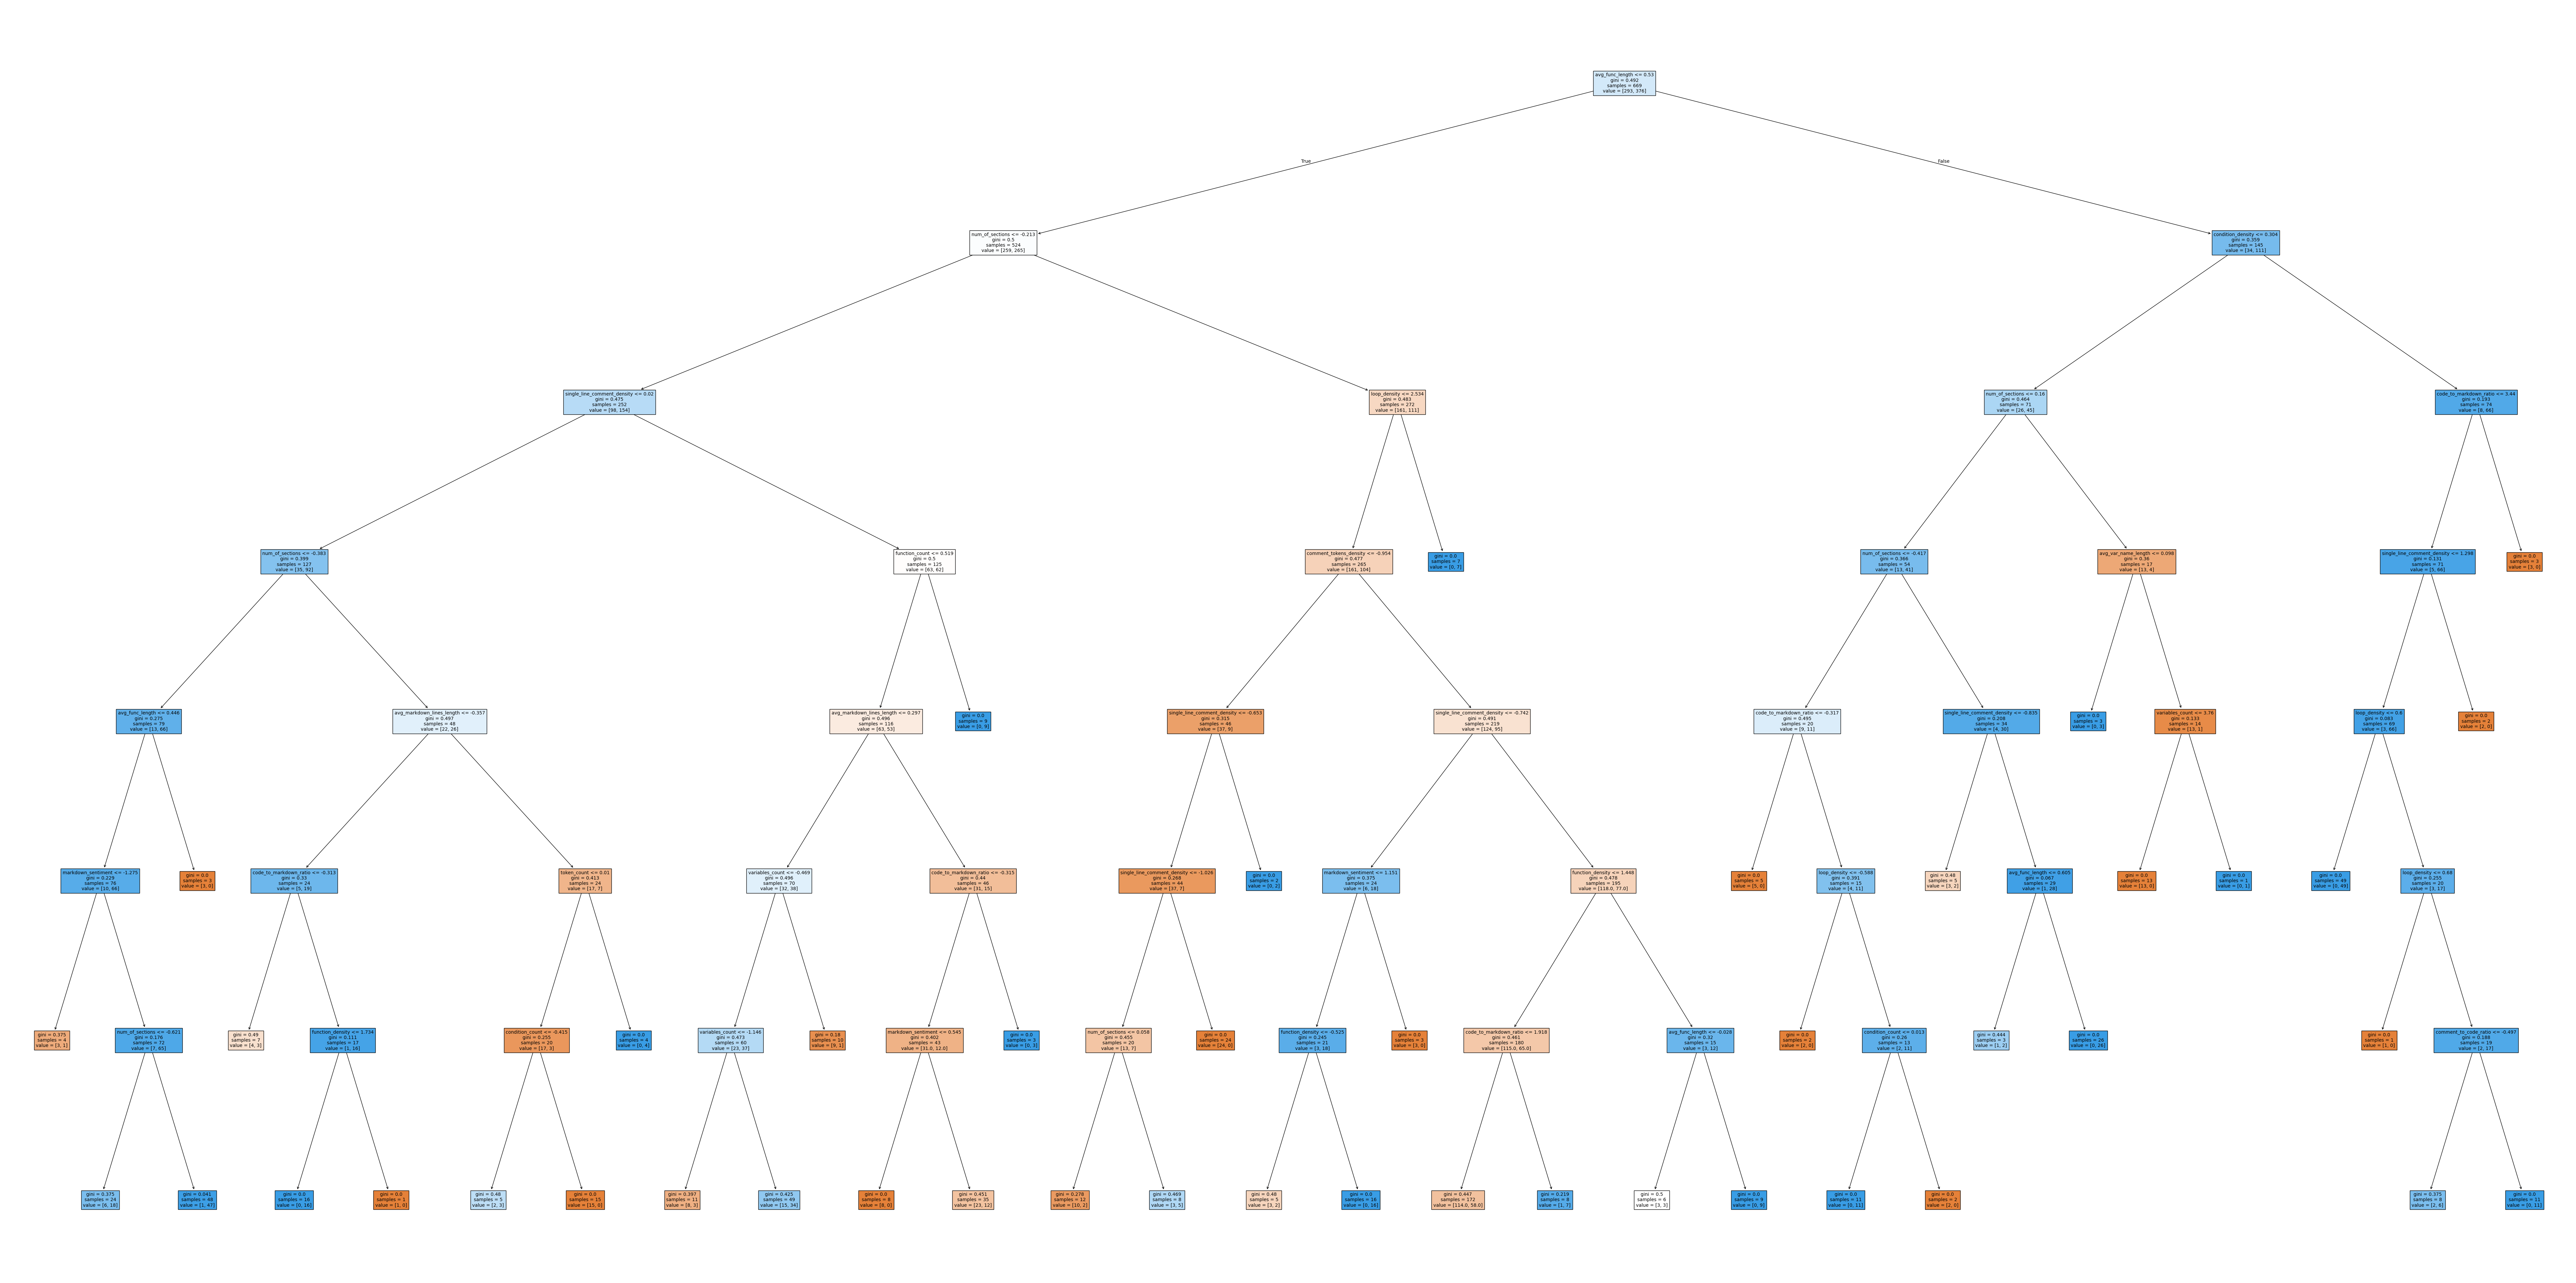

In [19]:
_, ax = plt.subplots(figsize=(100,50)) # Resize figure
plot_tree(best_dt['classifier'], filled=True, ax=ax, feature_names = X_train_nontext.columns.to_numpy())
plt.show()

# Random Forest

In [20]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',RandomForestClassifier())])

In [21]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6830658736393221


In [22]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [10, 20, 30],
    'classifier__bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found:  {'classifier__bootstrap': False, 'classifier__max_depth': 10, 'classifier__n_estimators': 50}
Best F1 score found:  0.6961913485997409
Test set F1 score:  0.6814285714285715


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      female       0.64      0.64      0.64        98
        male       0.72      0.72      0.72       125

    accuracy                           0.69       223
   macro avg       0.68      0.68      0.68       223
weighted avg       0.69      0.69      0.69       223



# KNN

In [24]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',KNeighborsClassifier())])

In [25]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.621871843788576


In [26]:
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}
Best F1 score found:  nan
Test set F1 score:  0.6120954692556635


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


# Support Vector Classifier

In [27]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',SVC(probability=True))])

In [28]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6787004825496578


In [29]:
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto'],
    'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found:  {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best F1 score found:  0.661600437342102
Test set F1 score:  0.6669432459342848


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      female       0.65      0.57      0.61        98
        male       0.69      0.76      0.73       125

    accuracy                           0.68       223
   macro avg       0.67      0.67      0.67       223
weighted avg       0.67      0.68      0.67       223

